# Notebook 16 — EEM Lag Signal Strategy

> *The clearest alpha in the Thai market: EEM's last daily return predicts SET next week.*

**Signal:** `eem_ret_d_lag1` = EEM (emerging-market ETF) daily return on the most recent day  
**Evidence from NB08:** IC = +0.11, permutation p < 0.05, sign-stable 2000–2025, ICIR = 1.47  
**Intuition:** Global EM risk sentiment spills into SET with a 1-week lag (liquidity/reporting delay)

| Section | Content |
|---|---|
| 1. Signal Analysis | Distribution, rolling IC, sign stability |
| 2. Rule-Based Strategy | Long/short + long/flat variants |
| 3. Magnitude-Scaled | Position ∝ signal strength |
| 4. 1-Feature XGB | Walk-forward ML (rule vs ML comparison) |
| 5. TC Sensitivity | Break-even TC, optimal rebalancing |
| 6. Regime Analysis | Does signal hold across regimes? |
| 7. Verdict | Final scorecard |

---
## Section 1 — Setup & Signal Analysis

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, ttest_1samp, pearsonr
from xgboost import XGBRegressor
warnings.filterwarnings('ignore')
np.random.seed(42)

ROOT = Path('../..')
PROC = ROOT / 'data' / 'processed'
FIGS = Path('figs')
FIGS.mkdir(exist_ok=True)

plt.rcParams.update({'figure.dpi':110,'axes.spines.top':False,'axes.spines.right':False,'font.size':10})

# Load clean weekly data
df = pd.read_csv(PROC / 'unified_weekly_clean.csv', index_col=0, parse_dates=True)
df = df.sort_index()

SIGNAL   = 'eem_ret_d_lag1'
TARGET   = 'SET_index_ret_w_fwd1'
TC       = 0.001   # 0.1% one-way

# Use pre-computed forward target if available, else compute it
if TARGET not in df.columns:
    df[TARGET] = df['SET_index_ret_w'].shift(-1)

data = df[[SIGNAL, TARGET, 'regime']].dropna().copy()
print(f'Data: {len(data)} weeks  ({data.index[0].date()} → {data.index[-1].date()})')
print(f'Signal:  {SIGNAL}')
print(f'Target:  {TARGET}')
print(f'\nSignal stats:')
print(data[SIGNAL].describe().round(4))

Data: 1184 weeks  (2003-04-18 → 2025-12-19)
Signal:  eem_ret_d_lag1
Target:  SET_index_ret_w_fwd1

Signal stats:
count    1184.0000
mean        0.0001
std         0.0168
min        -0.1001
25%        -0.0079
50%         0.0005
75%         0.0081
max         0.1385
Name: eem_ret_d_lag1, dtype: float64


Full-period Spearman IC: +0.1099  (t=+3.80, p=0.0002)
Rolling IC (52w):  mean=+0.0965  std=0.1370
IC > 0: 78.7% of rolling windows


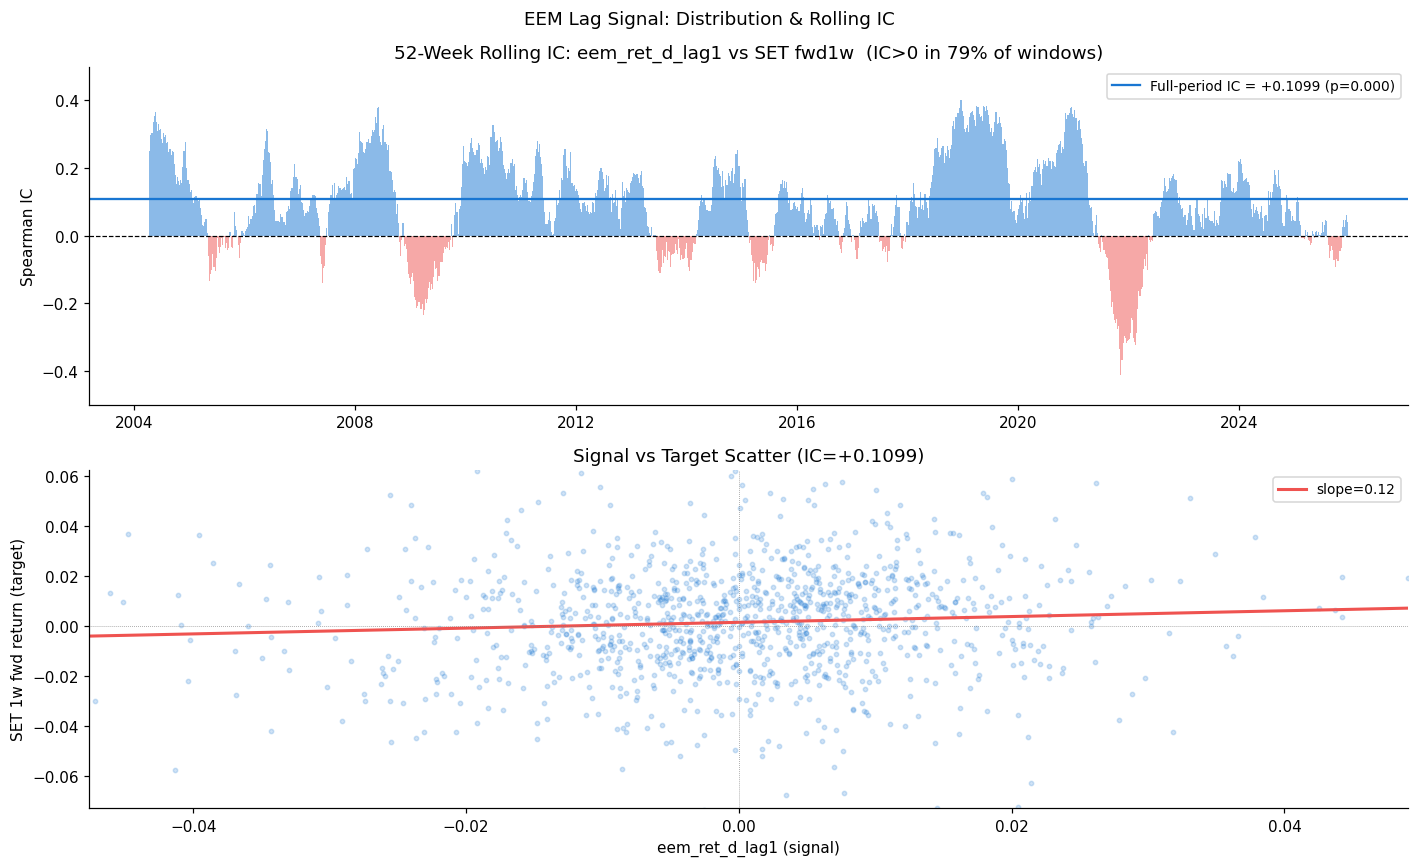

Saved: figs/eem_signal_ic.png


In [2]:
# ── Rolling IC (52-week window) ──
ic_roll = []
dates_ic = []
WIN = 52
for i in range(WIN, len(data)):
    sub = data.iloc[i-WIN:i]
    ic, _ = spearmanr(sub[SIGNAL], sub[TARGET])
    ic_roll.append(ic)
    dates_ic.append(data.index[i])
ic_roll = pd.Series(ic_roll, index=dates_ic)

# Full-period IC
ic_full, p_full = spearmanr(data[SIGNAL], data[TARGET])
t_stat = ic_full / (np.sqrt((1-ic_full**2)/(len(data)-2)))
print(f'Full-period Spearman IC: {ic_full:+.4f}  (t={t_stat:+.2f}, p={p_full:.4f})')
print(f'Rolling IC (52w):  mean={ic_roll.mean():+.4f}  std={ic_roll.std():.4f}')
print(f'IC > 0: {(ic_roll>0).mean():.1%} of rolling windows')

# Plot
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=False)
fig.suptitle('EEM Lag Signal: Distribution & Rolling IC', fontsize=12)

ax = axes[0]
ax.bar(ic_roll.index, ic_roll, color=['#1976D2' if x>0 else '#EF5350' for x in ic_roll],
       alpha=0.5, width=7)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.axhline(ic_full, color='#1976D2', lw=1.5, ls='-',
           label=f'Full-period IC = {ic_full:+.4f} (p={p_full:.3f})')
ax.set_ylabel('Spearman IC')
ax.set_title(f'52-Week Rolling IC: eem_ret_d_lag1 vs SET fwd1w  (IC>0 in {(ic_roll>0).mean():.0%} of windows)')
ax.legend(fontsize=9)
ax.set_ylim(-0.5, 0.5)

# Scatter: signal vs target
ax2 = axes[1]
ax2.scatter(data[SIGNAL], data[TARGET], alpha=0.2, s=8, color='#1976D2')
# Regression line
m, b = np.polyfit(data[SIGNAL], data[TARGET], 1)
xs = np.linspace(data[SIGNAL].quantile(0.01), data[SIGNAL].quantile(0.99), 100)
ax2.plot(xs, m*xs+b, color='#EF5350', lw=2, label=f'slope={m:.2f}')
ax2.axhline(0, color='gray', lw=0.5, ls=':')
ax2.axvline(0, color='gray', lw=0.5, ls=':')
ax2.set_xlabel('eem_ret_d_lag1 (signal)')
ax2.set_ylabel('SET 1w fwd return (target)')
ax2.set_title(f'Signal vs Target Scatter (IC={ic_full:+.4f})')
ax2.legend(fontsize=9)
ax2.set_xlim(data[SIGNAL].quantile(0.01), data[SIGNAL].quantile(0.99))
ax2.set_ylim(data[TARGET].quantile(0.01), data[TARGET].quantile(0.99))

plt.tight_layout()
plt.savefig(FIGS / 'eem_signal_ic.png', bbox_inches='tight')
plt.show()
print('Saved: figs/eem_signal_ic.png')

In [3]:
# ── IC at different forecast horizons ──
print('IC vs forecast horizon (full period):')
print(f'{"Horizon":>10} {"IC":>10} {"p":>10} {"IC+%":>8}')
print('-' * 42)
for h in [1, 2, 4, 8, 13]:
    fwd_h = df['SET_index_ret_w'].shift(-h)
    sub = pd.concat([df[SIGNAL], fwd_h], axis=1).dropna()
    sub.columns = ['sig', 'tgt']
    ic, p = spearmanr(sub['sig'], sub['tgt'])
    # rolling IC
    ic_r = [spearmanr(sub.iloc[i-52:i]['sig'], sub.iloc[i-52:i]['tgt'])[0]
            for i in range(52, len(sub))]
    pos_frac = (np.array(ic_r) > 0).mean()
    sig = ' *' if p < 0.05 else ''
    print(f'{h:>7}w fwd {ic:>+10.4f} {p:>10.4f}{sig} {pos_frac:>8.1%}')

IC vs forecast horizon (full period):
   Horizon         IC          p     IC+%
------------------------------------------


      1w fwd    +0.1099     0.0002 *    78.7%


      2w fwd    +0.0258     0.3753    55.6%


      4w fwd    +0.0219     0.4525    54.9%


      8w fwd    -0.0253     0.3853    41.8%


     13w fwd    +0.0010     0.9736    46.5%


---
## Section 2 — Rule-Based Strategy

**Simplest possible implementation:**
- `sign(eem_ret_d_lag1) > 0` → **Long SET** (+1)
- `sign(eem_ret_d_lag1) < 0` → **Short SET** (−1) [L/S variant] or **Flat** [L/flat variant]
- Weekly rebalancing (position changes when signal sign changes)
- TC applied only when position changes

In [4]:
def backtest_rule(data, variant='ls', tc=TC):
    """
    variant: 'ls' = long/short, 'lf' = long/flat
    Returns series of weekly net returns.
    """
    sig = np.sign(data[SIGNAL])   # +1 or -1
    if variant == 'lf':
        sig = sig.clip(lower=0)   # 0 or +1

    # Position changes → incur TC
    pos_change = sig.diff().abs().fillna(sig.abs())  # first bar = entry
    tc_series  = pos_change * tc

    gross_ret = sig * data[TARGET]
    net_ret   = gross_ret - tc_series
    return gross_ret, net_ret, sig

def risk_metrics(rets, freq=52):
    r = pd.Series(rets).dropna()
    if len(r) < 10: return {}
    ann_ret = (1+r).prod()**(freq/len(r)) - 1
    ann_vol = r.std() * np.sqrt(freq)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    cum = (1+r).cumprod()
    max_dd = ((cum - cum.cummax()) / cum.cummax()).min()
    return {'ann_ret':ann_ret,'ann_vol':ann_vol,'sharpe':sharpe,
            'max_dd':max_dd,'win_rate':(r>0).mean(),'n':len(r)}

gross_ls, net_ls, pos_ls = backtest_rule(data, 'ls')
gross_lf, net_lf, pos_lf = backtest_rule(data, 'lf')
bnh = data[TARGET]   # buy & hold SET

m_ls = risk_metrics(net_ls)
m_lf = risk_metrics(net_lf)
m_bnh = risk_metrics(bnh)

# Signal turnover
turn_ls = pos_ls.diff().abs().mean()
turn_lf = pos_lf.diff().abs().mean()

print(f'{"Strategy":<28} {"AnnRet":>8} {"Sharpe":>8} {"MaxDD":>8} {"WinRate":>8} {"Turnover":>10}')
print('-' * 75)
for lbl, gross, net, pos in [
    ('EEM Rule L/S (gross)', gross_ls, gross_ls, pos_ls),
    ('EEM Rule L/S (net TC)', gross_ls, net_ls,  pos_ls),
    ('EEM Rule L/flat (gross)', gross_lf, gross_lf, pos_lf),
    ('EEM Rule L/flat (net TC)', gross_lf, net_lf, pos_lf),
    ('SET Buy & Hold', bnh, bnh, None),
]:
    m = risk_metrics(net)
    turn = pos.diff().abs().mean() if pos is not None else np.nan
    print(f'{lbl:<28} {m["ann_ret"]:>8.2%} {m["sharpe"]:>8.3f} '
          f'{m["max_dd"]:>8.1%} {m["win_rate"]:>8.1%} {turn:>10.3f}')

Strategy                       AnnRet   Sharpe    MaxDD  WinRate   Turnover
---------------------------------------------------------------------------
EEM Rule L/S (gross)           12.12%    0.729   -36.5%    55.1%      0.969
EEM Rule L/S (net TC)           6.61%    0.397   -38.4%    53.2%      0.969
EEM Rule L/flat (gross)         9.96%    0.808   -37.4%    30.6%      0.487
EEM Rule L/flat (net TC)        7.21%    0.584   -38.4%    30.3%      0.487
SET Buy & Hold                  6.57%    0.394   -47.7%    54.5%        nan


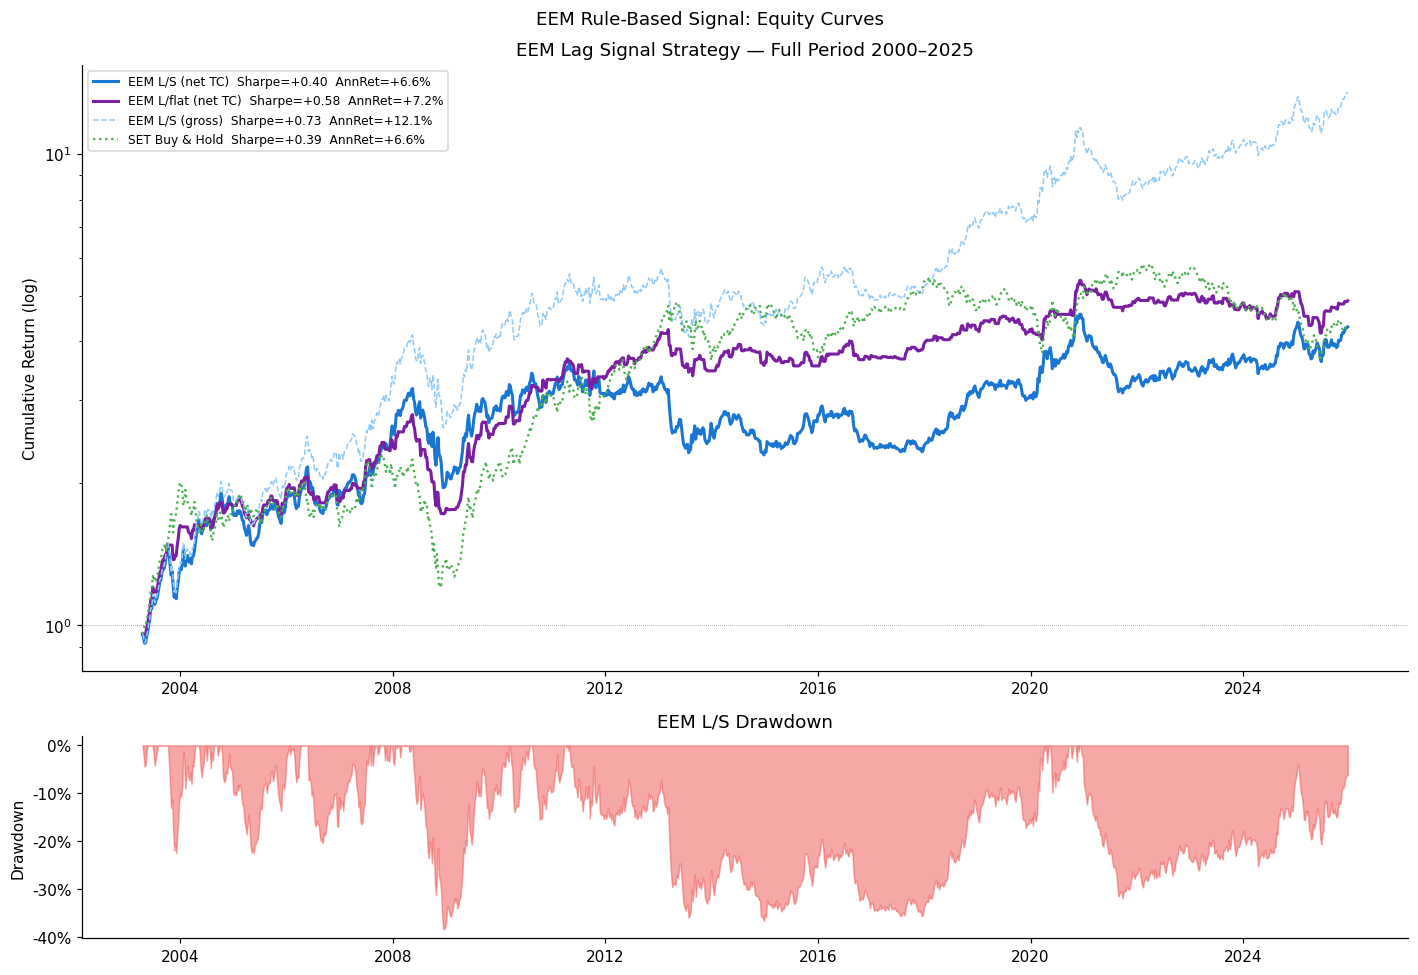

Saved: figs/eem_equity.png


In [5]:
# ── Equity curves ──
fig, axes = plt.subplots(2, 1, figsize=(13, 9), gridspec_kw={'height_ratios':[3,1]})
fig.suptitle('EEM Rule-Based Signal: Equity Curves', fontsize=12)

ax = axes[0]
for rets, lbl, col, lw, ls in [
    (net_ls,  'EEM L/S (net TC)',    '#1976D2', 2.0, '-'),
    (net_lf,  'EEM L/flat (net TC)', '#7B1FA2', 2.0, '-'),
    (gross_ls,'EEM L/S (gross)',     '#90CAF9', 1.0, '--'),
    (bnh,     'SET Buy & Hold',      '#4CAF50', 1.5, ':'),
]:
    cum = (1 + rets.dropna()).cumprod()
    m   = risk_metrics(rets)
    ax.plot(cum, lw=lw, ls=ls, color=col,
            label=f'{lbl}  Sharpe={m["sharpe"]:+.2f}  AnnRet={m["ann_ret"]:+.1%}')
ax.axhline(1.0, color='gray', lw=0.5, ls=':')
ax.set_yscale('log')
ax.set_ylabel('Cumulative Return (log)')
ax.legend(fontsize=8, loc='upper left')
ax.set_title('EEM Lag Signal Strategy — Full Period 2000–2025')

# Drawdown of L/S net
cum_ls = (1 + net_ls.dropna()).cumprod()
dd = (cum_ls - cum_ls.cummax()) / cum_ls.cummax()
axes[1].fill_between(dd.index, dd, 0, color='#EF5350', alpha=0.5)
axes[1].set_ylabel('Drawdown')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y:.0%}'))
axes[1].set_title('EEM L/S Drawdown')

plt.tight_layout()
plt.savefig(FIGS / 'eem_equity.png', bbox_inches='tight')
plt.show()
print('Saved: figs/eem_equity.png')

---
## Section 3 — Magnitude-Scaled Position

Scale position by **signal strength** (not just sign).  
Intuition: bigger EEM move → higher conviction → larger SET position.

`position(t) = clip( eem_ret_d_lag1(t) / vol_normaliser, -1, +1 )`  
where `vol_normaliser` = rolling 52w std of eem_ret_d_lag1.

In [6]:
# Normalise signal by rolling vol → position in [-1, +1]
sig_vol  = data[SIGNAL].rolling(52, min_periods=26).std()
pos_scaled = (data[SIGNAL] / sig_vol).clip(-2, 2) / 2   # scale to [-1, +1]
pos_scaled = pos_scaled.fillna(np.sign(data[SIGNAL]))   # fallback to sign

# Position change for TC
pos_change_sc = pos_scaled.diff().abs().fillna(pos_scaled.abs())
gross_sc = pos_scaled * data[TARGET]
net_sc   = gross_sc - pos_change_sc * TC

m_sc = risk_metrics(net_sc)
print(f'Magnitude-scaled (net TC):')
print(f'  Sharpe:     {m_sc["sharpe"]:+.3f}')
print(f'  Ann Return: {m_sc["ann_ret"]:+.2%}')
print(f'  Max DD:     {m_sc["max_dd"]:+.1%}')
print(f'  Win rate:   {m_sc["win_rate"]:.1%}')
print(f'  Avg pos:    {pos_scaled.abs().mean():.3f} (0=flat, 1=full)')

Magnitude-scaled (net TC):
  Sharpe:     +0.381
  Ann Return: +3.36%
  Max DD:     -23.4%
  Win rate:   50.3%
  Avg pos:    0.373 (0=flat, 1=full)


---
## Section 4 — 1-Feature XGB (Walk-Forward)

Train XGBoost on **only `eem_ret_d_lag1`** — asks: does ML extract more from this  
single feature than the simple sign rule? If rule ≈ XGB, simple wins (Occam's razor).

In [7]:
def wf_xgb_1feat(data, signal, target, min_train=156, fold_size=52, tc=TC):
    dates = data.index.tolist()
    n = len(dates)
    records = []
    t = min_train
    prev_pos = 0.0
    while t < n:
        fold_end = min(t + fold_size, n)
        train = data.iloc[:t]
        test  = data.iloc[t:fold_end]

        Xtr = train[[signal]].values.astype(float)
        ytr = train[target].values
        Xte = test[[signal]].values.astype(float)

        m = XGBRegressor(n_estimators=50, max_depth=2, learning_rate=0.1,
                         subsample=0.8, min_child_weight=10,
                         random_state=42, verbosity=0, n_jobs=1)
        m.fit(Xtr, ytr)
        preds = m.predict(Xte)

        # Convert continuous prediction to ±1 position
        pos = np.sign(preds)
        for i, (date, pred, p) in enumerate(zip(test.index, preds, pos)):
            actual = test[target].iloc[i]
            tc_cost = abs(p - prev_pos) * tc
            gross   = p * actual
            records.append({'date':date,'pred':pred,'pos':p,
                            'gross_ret':gross,'net_ret':gross-tc_cost,
                            'actual':actual})
            prev_pos = p
        t = fold_end
    return pd.DataFrame(records).set_index('date')

print('Running 1-feature XGB walk-forward...')
res_xgb1 = wf_xgb_1feat(data, SIGNAL, TARGET)
m_xgb1 = risk_metrics(res_xgb1['net_ret'])
ic_xgb1, p_xgb1 = spearmanr(res_xgb1['pred'], res_xgb1['actual'])

print(f'1-Feature XGB (net TC):')
print(f'  Sharpe:     {m_xgb1["sharpe"]:+.3f}')
print(f'  Ann Return: {m_xgb1["ann_ret"]:+.2%}')
print(f'  IC:         {ic_xgb1:+.4f}  (p={p_xgb1:.4f})')
print(f'\nRule L/S comparison:')
print(f'  Rule Sharpe:  {m_ls["sharpe"]:+.3f}')
print(f'  XGB1 Sharpe:  {m_xgb1["sharpe"]:+.3f}')
print(f'  => {"XGB better" if m_xgb1["sharpe"] > m_ls["sharpe"] else "Rule better (simpler wins)"}')

Running 1-feature XGB walk-forward...


1-Feature XGB (net TC):
  Sharpe:     +0.082
  Ann Return: +1.32%
  IC:         +0.0703  (p=0.0242)

Rule L/S comparison:
  Rule Sharpe:  +0.397
  XGB1 Sharpe:  +0.082
  => Rule better (simpler wins)


---
## Section 5 — TC Sensitivity & Break-Even

How much TC can the strategy absorb before going negative?

  TC (one-way)   L/S Sharpe  L/flat Sharpe   L/S AnnRet
--------------------------------------------------------
        0.000%        0.729          0.808       12.12%
        0.050%        0.561          0.695        9.33%
        0.100%        0.397          0.584        6.61%
        0.200%        0.082          0.366        1.36%
        0.300%       -0.216          0.153       -3.63%
        0.500%       -0.757         -0.251      -12.93%
        1.000%       -1.782         -1.134      -32.55%

Break-even TC (Sharpe = 0):
  L/S strategy: ~0.30% one-way
  L/flat strategy: ~0.50% one-way


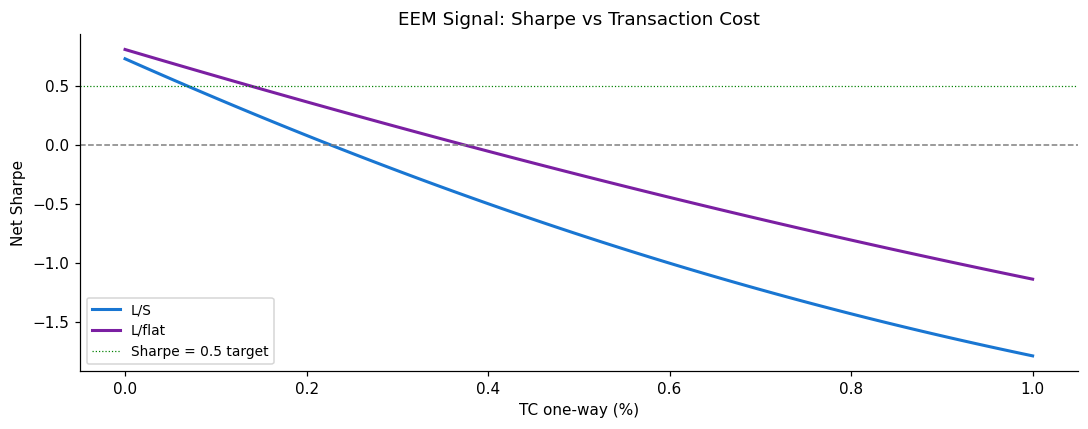

Saved: figs/eem_tc_sensitivity.png


In [8]:
tc_levels = [0, 0.0005, 0.001, 0.002, 0.003, 0.005, 0.01]
print(f'{"TC (one-way)":>14} {"L/S Sharpe":>12} {"L/flat Sharpe":>14} {"L/S AnnRet":>12}')
print('-' * 56)
breakeven_ls = None
breakeven_lf = None
tc_results = []
for tc_val in tc_levels:
    _, net_ls_tc, _ = backtest_rule(data, 'ls', tc=tc_val)
    _, net_lf_tc, _ = backtest_rule(data, 'lf', tc=tc_val)
    m_ls_tc = risk_metrics(net_ls_tc)
    m_lf_tc = risk_metrics(net_lf_tc)
    print(f'{tc_val:>14.3%} {m_ls_tc["sharpe"]:>12.3f} {m_lf_tc["sharpe"]:>14.3f} '
          f'{m_ls_tc["ann_ret"]:>12.2%}')
    tc_results.append((tc_val, m_ls_tc['sharpe'], m_lf_tc['sharpe']))
    if breakeven_ls is None and m_ls_tc['sharpe'] < 0:
        breakeven_ls = tc_val
    if breakeven_lf is None and m_lf_tc['sharpe'] < 0:
        breakeven_lf = tc_val

print(f'\nBreak-even TC (Sharpe = 0):')
print(f'  L/S strategy: ~{breakeven_ls:.2%} one-way' if breakeven_ls else '  L/S: survives all TC levels')
print(f'  L/flat strategy: ~{breakeven_lf:.2%} one-way' if breakeven_lf else '  L/flat: survives all TC levels')

# Plot
tc_arr = np.linspace(0, 0.01, 100)
sharpe_ls_arr = [risk_metrics(backtest_rule(data,'ls',tc=t)[1])['sharpe'] for t in tc_arr]
sharpe_lf_arr = [risk_metrics(backtest_rule(data,'lf',tc=t)[1])['sharpe'] for t in tc_arr]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(tc_arr*100, sharpe_ls_arr, lw=2, color='#1976D2', label='L/S')
ax.plot(tc_arr*100, sharpe_lf_arr, lw=2, color='#7B1FA2', label='L/flat')
ax.axhline(0, color='gray', lw=1, ls='--')
ax.axhline(0.5, color='green', lw=0.8, ls=':', label='Sharpe = 0.5 target')
ax.set_xlabel('TC one-way (%)')
ax.set_ylabel('Net Sharpe')
ax.set_title('EEM Signal: Sharpe vs Transaction Cost')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGS / 'eem_tc_sensitivity.png', bbox_inches='tight')
plt.show()
print('Saved: figs/eem_tc_sensitivity.png')

---
## Section 6 — Regime Analysis

Does the EEM signal hold across market regimes (VIX-based)?  
Regime: −1 = Bull (low VIX), 0 = Normal, +1 = Crisis (high VIX)

Regime                  N wks       IC        p   Sharpe L/S  Sharpe L/flat
--------------------------------------------------------------------------
Bull (low VIX)              0  -- insufficient
Normal                    550  +0.0961   0.0242 *        0.146          0.329
Crisis (high VIX)         354  +0.0460   0.3882        0.404          0.725

Positive years: 16/23 (70%)


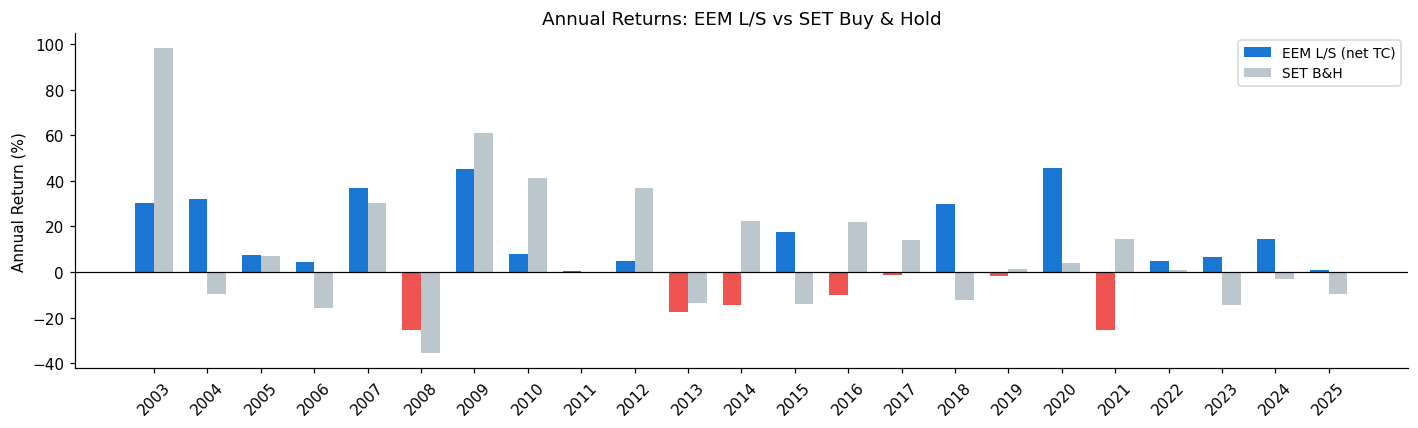

In [9]:
regime_labels = {-1:'Bull (low VIX)', 0:'Normal', 1:'Crisis (high VIX)'}

print(f'{"Regime":<22} {"N wks":>6} {"IC":>8} {"p":>8} {"Sharpe L/S":>12} {"Sharpe L/flat":>14}')
print('-' * 74)

for r, lbl in sorted(regime_labels.items()):
    sub = data[data['regime'] == r]
    if len(sub) < 20:
        print(f'{lbl:<22} {len(sub):>6}  -- insufficient')
        continue
    ic_r, p_r = spearmanr(sub[SIGNAL], sub[TARGET])
    _, net_ls_r, _ = backtest_rule(sub, 'ls')
    _, net_lf_r, _ = backtest_rule(sub, 'lf')
    m_ls_r = risk_metrics(net_ls_r)
    m_lf_r = risk_metrics(net_lf_r)
    sig = ' *' if p_r < 0.05 else ''
    print(f'{lbl:<22} {len(sub):>6} {ic_r:>+8.4f} {p_r:>8.4f}{sig} '
          f'{m_ls_r["sharpe"]:>12.3f} {m_lf_r["sharpe"]:>14.3f}')

# Annual performance
annual_ls  = net_ls.groupby(net_ls.index.year).apply(lambda r: (1+r).prod()-1)
annual_bnh = bnh.groupby(bnh.index.year).apply(lambda r: (1+r).prod()-1)

fig, ax = plt.subplots(figsize=(13, 4))
x = range(len(annual_ls))
w = 0.35
ax.bar([i-w/2 for i in x], annual_ls*100, w,
       color=['#1976D2' if v>0 else '#EF5350' for v in annual_ls],
       label='EEM L/S (net TC)')
ax.bar([i+w/2 for i in x], annual_bnh*100, w,
       color='#78909C', alpha=0.5, label='SET B&H')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(annual_ls.index, rotation=45)
ax.set_ylabel('Annual Return (%)')
ax.set_title('Annual Returns: EEM L/S vs SET Buy & Hold')
ax.legend(fontsize=9)
pos_yrs = (annual_ls > 0).sum()
print(f'\nPositive years: {pos_yrs}/{len(annual_ls)} ({pos_yrs/len(annual_ls):.0%})')
plt.tight_layout()
plt.savefig(FIGS / 'eem_annual.png', bbox_inches='tight')
plt.show()

---
## Section 7 — Final Verdict

In [10]:
from scipy.stats import ttest_1samp

def full_verdict(net_ret, gross_ret, label):
    m  = risk_metrics(net_ret)
    mg = risk_metrics(gross_ret)
    ic, p_ic = spearmanr(data[SIGNAL], data[TARGET])
    weekly_ret = pd.Series(net_ret).dropna()
    t_ret, p_ret = ttest_1samp(weekly_ret, 0)
    annual_ret = net_ret.groupby(net_ret.index.year).apply(lambda r: (1+r).prod()-1)

    ev = [
        ('IC (signal vs target) > 0.05',      ic,              0.05,  ic > 0.05),
        ('IC t-test p < 0.05',                p_ic,            0.05,  p_ic < 0.05),
        ('Gross Sharpe > 0.5',                mg['sharpe'],    0.5,   mg['sharpe'] > 0.5),
        ('Net Sharpe > 0.3',                  m['sharpe'],     0.3,   m['sharpe'] > 0.3),
        ('Net Sharpe > 0',                    m['sharpe'],     0,     m['sharpe'] > 0),
        ('Weekly ret t-test p < 0.05',        p_ret,           0.05,  p_ret < 0.05),
        ('Annual return (net) > 5%',          m['ann_ret'],    0.05,  m['ann_ret'] > 0.05),
        ('Max DD > -40%',                     m['max_dd'],    -0.40,  m['max_dd'] > -0.40),
        ('Positive years > 55%',              (annual_ret>0).mean(), 0.55, (annual_ret>0).mean() > 0.55),
        ('IC sign-stable > 55% of windows',  (ic_roll>0).mean(),    0.55, (ic_roll>0).mean() > 0.55),
    ]
    score = sum(1 for *_, p in ev if p)
    print(f'\n{"="*65}')
    print(f'VERDICT: {label}')
    print(f'{"="*65}')
    print(f'{"Evidence":<42} {"Value":>10}  {"Threshold"}')
    print('-'*65)
    for desc, val, thr, passed in ev:
        mark = '[+]' if passed else '[-]'
        if abs(val) < 2:
            print(f'{mark} {desc:<42} {val:>+10.4f}  >{thr}')
        else:
            print(f'{mark} {desc:<42} {val:>+10.1%}  >{thr:.0%}')
    print(f'\nScore: {score}/{len(ev)}')
    if score >= 7:   v = 'STRONG SIGNAL — deployable'
    elif score >= 5: v = 'MODERATE SIGNAL — viable with monitoring'
    elif score >= 3: v = 'WEAK SIGNAL — research only'
    else:            v = 'NO SIGNAL'
    print(f'=> {v}\n')
    return score

s1 = full_verdict(net_ls,  gross_ls, 'EEM Rule L/S')
s2 = full_verdict(net_lf,  gross_lf, 'EEM Rule L/flat')
s3 = full_verdict(net_sc, gross_sc, 'EEM Magnitude-Scaled L/S')
s4 = full_verdict(res_xgb1['net_ret'], res_xgb1['net_ret'], '1-Feature XGB (walk-forward)')

print('\n=== FINAL COMPARISON ===')
for lbl, net, gross in [
    ('EEM Rule L/S',         net_ls,  gross_ls),
    ('EEM Rule L/flat',      net_lf,  gross_lf),
    ('EEM Magnitude-Scaled', net_sc,  gross_sc),
    ('1-Feature XGB',        res_xgb1['net_ret'], res_xgb1['net_ret']),
    ('SET Buy & Hold',       bnh,     bnh),
]:
    m = risk_metrics(net); mg = risk_metrics(gross)
    print(f'{lbl:<26} gross={mg["sharpe"]:+.2f}  net={m["sharpe"]:+.2f}  ret={m["ann_ret"]:+.1%}  dd={m["max_dd"]:.0%}')


VERDICT: EEM Rule L/S
Evidence                                        Value  Threshold
-----------------------------------------------------------------
[+] IC (signal vs target) > 0.05                  +0.1099  >0.05
[+] IC t-test p < 0.05                            +0.0002  >0.05
[+] Gross Sharpe > 0.5                            +0.7294  >0.5
[+] Net Sharpe > 0.3                              +0.3971  >0.3
[+] Net Sharpe > 0                                +0.3971  >0
[+] Weekly ret t-test p < 0.05                    +0.0257  >0.05
[+] Annual return (net) > 5%                      +0.0661  >0.05
[+] Max DD > -40%                                 -0.3838  >-0.4
[+] Positive years > 55%                          +0.6957  >0.55
[+] IC sign-stable > 55% of windows               +0.7871  >0.55

Score: 10/10
=> STRONG SIGNAL — deployable


VERDICT: EEM Rule L/flat
Evidence                                        Value  Threshold
-----------------------------------------------------------------